# 06 · Evaluation

| | |
|---|---|
| **入力** | 学習済み重み（05）+ テスト窓（04） |
| **出力** | テスト精度, 混同行列, 精度 vs 遷移オフセット曲線 |

主眼は **動作遷移の周辺で意図をどれだけ早く読み出せるか**. テスト窓を各ラベル 変化点に対して −400 ms 〜 +400 ms ずらして再抽出し, 特徴量セットごとに精度を オフセットに対してプロットする. チャンスレベルは 1/7 ≈ 14.3%.

In [1]:
import sys
from pathlib import Path

# notebooks/ から実行したときに motion_intent パッケージを import 可能にする
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from motion_intent import config

In [2]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns

from motion_intent.datasets import FeatureDataset, ConcatFeatureDataset
from motion_intent.models import FNN_OnlyEEG, FNN_NonEEG, FNN_Fusion
from motion_intent.training import eval_epoch

## Load test features and weights

In [4]:
subject = 'haru'      # ← 自分の被験者フォルダ名に変更
feat_dir = config.DATA_DIR / 'features'
ckpt_dir = config.DATA_DIR / 'checkpoints' / subject
assert (feat_dir / f'{subject}_test.npz').exists(), 'run notebook 04 first'
assert ckpt_dir.exists() and any(ckpt_dir.glob('*.pth')), 'run notebook 05 first'
te = dict(np.load(feat_dir / f'{subject}_test.npz'))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

m_noneeg = FNN_NonEEG(te['motion'].shape[1], te['rms'].shape[1])
m_hjorth = FNN_Fusion(te['hjorth'].shape[1], te['motion'].shape[1], te['rms'].shape[1])
m_eeg    = FNN_OnlyEEG(te['hjorth'].shape[1])
for name, model in [('noneeg', m_noneeg), ('hjorth', m_hjorth), ('eeg', m_eeg)]:
    model.load_state_dict(torch.load(ckpt_dir / f'{name}.pth', map_location=device))
    model.eval()

## Test accuracy & confusion matrix

Hjorth fusion test accuracy: 0.855


Text(0.5, 1.0, 'Hjorth fusion')

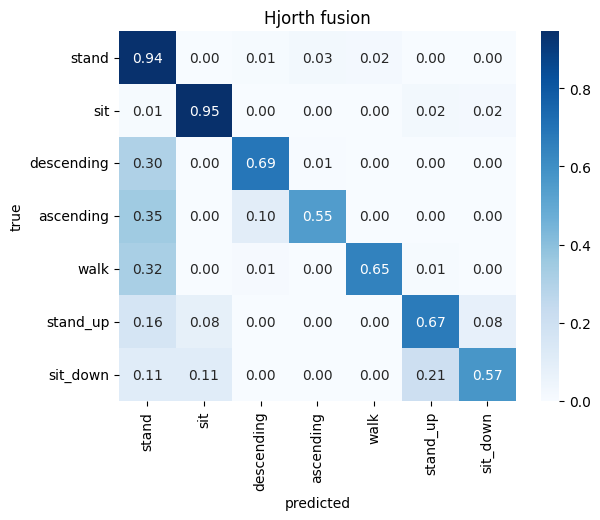

In [5]:
loader = DataLoader(FeatureDataset(te['y'], X_eeg=te['hjorth'],
                                   X_motion=te['motion'], X_emg=te['rms']),
                    batch_size=64)
acc, y_true, y_pred = eval_epoch(m_hjorth, loader, device)
print(f'Hjorth fusion test accuracy: {acc:.3f}')

cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Hjorth fusion')

## Accuracy vs. transition offset

ノートブック 04 が書き出した `data/features/<subject>_offset_<ms>.npz`（遷移点に 対して各オフセットで再窓化したテスト集合）を読み, 各モデルを評価する.

In [6]:
offsets_ms = list(range(-config.OFFSET_RANGE_MS, config.OFFSET_RANGE_MS + 1,
                        config.OFFSET_STEP_MS))

def accuracy_by_offset(model, feat_key, concat=False):
    accs = []
    for ms in offsets_ms:
        off = dict(np.load(feat_dir / f'{subject}_offset_{ms}.npz'))
        if concat:
            ds = ConcatFeatureDataset(off['y'], off[feat_key])
        else:
            ds = FeatureDataset(off['y'], X_eeg=off.get(feat_key),
                                X_motion=off['motion'], X_emg=off['rms'])
        a, _, _ = eval_epoch(model, DataLoader(ds, batch_size=64), device)
        accs.append(a)
    return accs

curves = {
    'non-EEG': accuracy_by_offset(m_noneeg, None),
    'Hjorth':  accuracy_by_offset(m_hjorth, 'hjorth'),
}

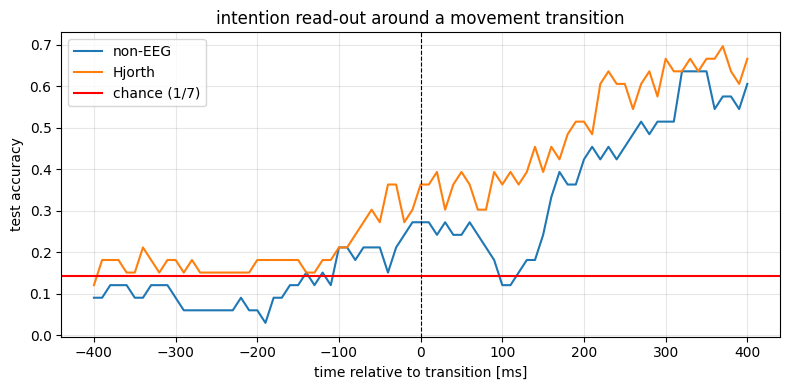

In [7]:
plt.figure(figsize=(8, 4))
for name, ys in curves.items():
    plt.plot(offsets_ms, ys, label=name)
plt.axhline(1 / config.N_CLASSES, color='red', label='chance (1/7)')
plt.axvline(0, color='k', ls='--', lw=0.8)
plt.xlabel('time relative to transition [ms]')
plt.ylabel('test accuracy')
plt.title('intention read-out around a movement transition')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## Results table

In [8]:
tbl = pd.DataFrame(curves, index=offsets_ms)
tbl.index.name = 'offset_ms'
tbl.round(3)

,non-EEG,Hjorth
offset_ms,,
-400,0.091,0.121
-390,0.091,0.182
-380,0.121,0.182
-370,0.121,0.182
-360,0.121,0.152
...,...,...
360,0.545,0.667
370,0.576,0.697
380,0.576,0.636
